In [1]:
!pip install openpyxl scikit-learn matplotlib pandas numpy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Telco-Customer-Churn.csv to Telco-Customer-Churn.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [4]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nData types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isnull().sum())

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:

customerID   

In [6]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

11


In [7]:
df = df.dropna().copy()
print("New shape after dropping missing rows:", df.shape)

New shape after dropping missing rows: (7032, 21)


In [8]:
print(df["Churn"].value_counts())
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [9]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"No": 0, "Yes": 1})

In [10]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [11]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [12]:
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
knn_model = KNeighborsClassifier(n_neighbors=7)
nb_model = GaussianNB()

In [13]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", dt_model)
])

knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", knn_model)
])

In [14]:
categorical_transformer_dense = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_dense = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer_dense, categorical_features)
])

nb_pipeline = Pipeline([
    ("preprocessor", preprocessor_dense),
    ("classifier", nb_model)
])

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy"
}

In [16]:
models = {
    "Decision Tree": dt_pipeline,
    "kNN": knn_pipeline,
    "Naive Bayes": nb_pipeline
}

results = []

for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

    results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.789958,0.615124,0.558551,0.584896,0.827702
1,kNN,0.768344,0.568460,0.536110,0.551650,0.791238
2,Naive Bayes,0.693970,0.458919,0.844306,0.594575,0.817535


In [ ]:
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Naive Bayes,0.693970,0.458919,0.844306,0.594575,0.817535
1,Decision Tree,0.789958,0.615124,0.558551,0.584896,0.827702
2,kNN,0.768344,0.568460,0.536110,0.551650,0.791238


In [17]:
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")

    print(f"\n{name}")
    print(classification_report(y, y_pred, digits=4))


Decision Tree
              precision    recall  f1-score   support

           0     0.8454    0.8737    0.8593      5163
           1     0.6156    0.5586    0.5857      1869

    accuracy                         0.7900      7032
   macro avg     0.7305    0.7162    0.7225      7032
weighted avg     0.7843    0.7900    0.7866      7032


kNN
              precision    recall  f1-score   support

           0     0.8354    0.8524    0.8438      5163
           1     0.5680    0.5361    0.5516      1869

    accuracy                         0.7683      7032
   macro avg     0.7017    0.6943    0.6977      7032
weighted avg     0.7644    0.7683    0.7662      7032


Naive Bayes
              precision    recall  f1-score   support

           0     0.9190    0.6396    0.7542      5163
           1     0.4589    0.8443    0.5946      1869

    accuracy                         0.6940      7032
   macro avg     0.6889    0.7419    0.6744      7032
weighted avg     0.7967    0.6940    0.71

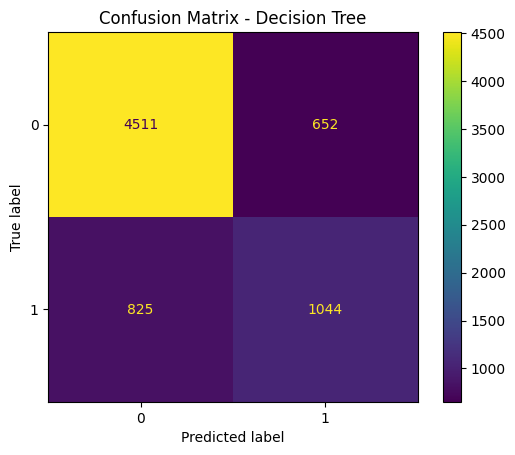

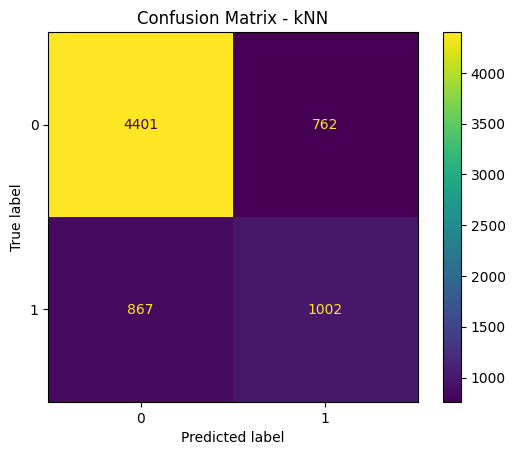

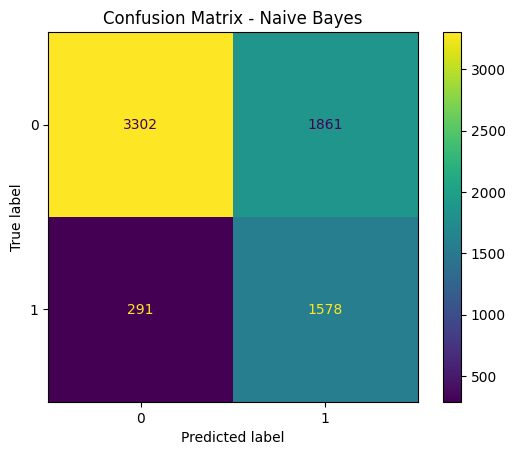

In [18]:
for name, model in models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv, method="predict")
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

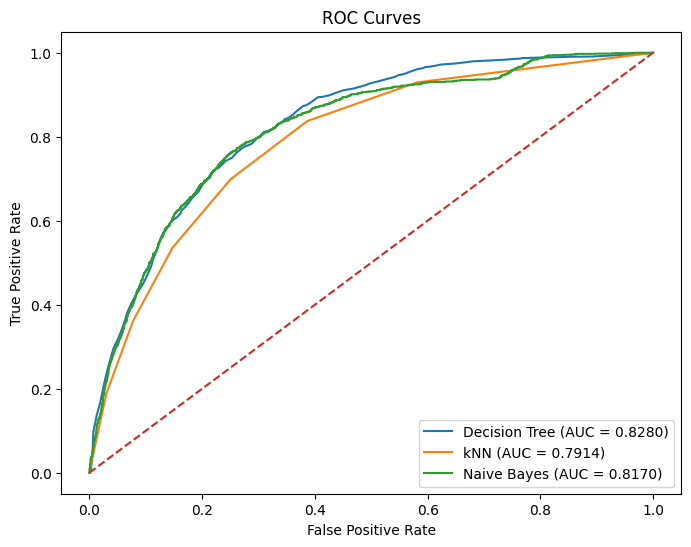

In [19]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, y_proba)
    auc_score = roc_auc_score(y, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

In [20]:
dt_param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4]
}

dt_grid = GridSearchCV(
    dt_pipeline,
    param_grid=dt_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_grid.fit(X, y)

print("Best DT params:", dt_grid.best_params_)
print("Best DT F1:", dt_grid.best_score_)

Best DT params: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best DT F1: 0.5856158606355428


In [21]:
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["minkowski"]
}

knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X, y)

print("Best kNN params:", knn_grid.best_params_)
print("Best kNN F1:", knn_grid.best_score_)

Best kNN params: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Best kNN F1: 0.569965964100238


In [22]:
nb_param_grid = {
    "classifier__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]
}

nb_grid = GridSearchCV(
    nb_pipeline,
    param_grid=nb_param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

nb_grid.fit(X, y)

print("Best NB params:", nb_grid.best_params_)
print("Best NB F1:", nb_grid.best_score_)

Best NB params: {'classifier__var_smoothing': 1e-09}
Best NB F1: 0.5945753618384296


In [23]:
best_dt = dt_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_nb = nb_grid.best_estimator_

In [24]:
tuned_models = {
    "Decision Tree ": best_dt,
    "kNN ": best_knn,
    "Naive Bayes ": best_nb
}

tuned_results = []

for name, model in tuned_models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)

    tuned_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1-score": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean()
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Decision Tree,0.7904,0.6161,0.5591,0.5856,0.8280
1,kNN,0.7799,0.5929,0.5490,0.5700,0.8118
2,Naive Bayes,0.6940,0.4589,0.8443,0.5946,0.8175


In [25]:
voting_model = VotingClassifier(
    estimators=[
        ("dt", best_dt),
        ("knn", best_knn),
        ("nb", best_nb)
    ],
    voting="soft"
)

In [26]:
voting_scores = cross_validate(voting_model, X, y, cv=cv, scoring=scoring)

voting_result = pd.DataFrame([{
    "Model": "Hybrid Soft Voting",
    "Accuracy": voting_scores["test_accuracy"].mean(),
    "Precision": voting_scores["test_precision"].mean(),
    "Recall": voting_scores["test_recall"].mean(),
    "F1-score": voting_scores["test_f1"].mean(),
    "ROC-AUC": voting_scores["test_roc_auc"].mean()
}])

voting_result.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Hybrid Soft Voting,0.7486,0.5181,0.7758,0.6213,0.8353


In [27]:
final_results = pd.concat([tuned_results_df, voting_result], ignore_index=True)
final_results = final_results.sort_values(by="F1-score", ascending=False).reset_index(drop=True)
final_results.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Hybrid Soft Voting,0.7486,0.5181,0.7758,0.6213,0.8353
1,Naive Bayes,0.6940,0.4589,0.8443,0.5946,0.8175
2,Decision Tree,0.7904,0.6161,0.5591,0.5856,0.8280
3,kNN,0.7799,0.5929,0.5490,0.5700,0.8118


In [28]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(voting_model, X, y, cv=cv, method="predict")

In [29]:
cm = confusion_matrix(y, y_pred)
print(cm)

[[3814 1349]
 [ 419 1450]]


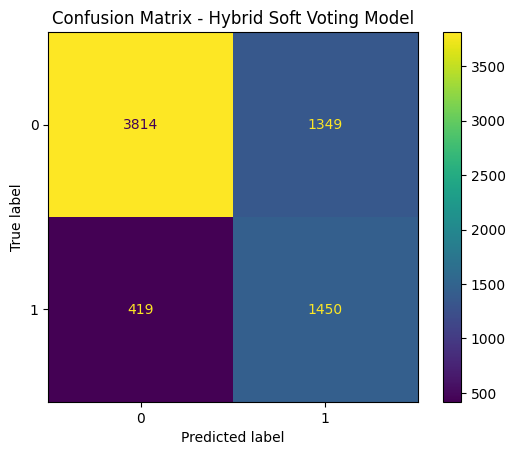

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Hybrid Soft Voting Model")
plt.show()